In [8]:
%pip install pandas
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Bonato\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Bonato\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
# =========================
# IMPORTS
# =========================

import pandas as pd
from collections import deque
import matplotlib.pyplot as plt

# =========================
# CARREGAMENTO DOS DADOS (RM FINAL ÍMPAR)
# =========================

df = pd.read_csv('./Check_point_1_dados_logistica_RA_final_impar.csv')


In [10]:
# =========================
# CLASSIFICAÇÃO DE VALOR (lambda)
# =========================

df["faixa_valor"] = df["valor_frete"].apply(
    lambda x: "alto" if x >= 1600 else "medio" if x >= 1200 else "baixo"
)

In [11]:
# =========================
# SCORE BASE (VETORIZADO)
# =========================
# Complexidade: O(n)

df["valor_prioridade"] = 0

df["valor_prioridade"] += df["prioridade_cliente"].map({
    "vip": 3
}).fillna(1)

df["valor_prioridade"] += df["situacao_rota"].map({
    "critica": 3,
    "atencao": 2
}).fillna(1)

df["valor_prioridade"] += df["faixa_valor"].map({
    "alto": 2,
    "medio": 1
}).fillna(0)

In [12]:
# =========================
# INTERAÇÕES (REGRAS DE NEGÓCIO)
# =========================

df["valor_prioridade"] += (
    (df["situacao_rota"] == "critica") &
    (df["prazo_dias"] <= 3)
) * 3

df["valor_prioridade"] += (
    (df["prioridade_cliente"] == "vip") &
    (df["faixa_valor"] == "alto")
) * 2

df["valor_prioridade"] += (
    (df["situacao_rota"] == "critica") &
    (df["prioridade_cliente"] == "vip")
) * 2

df["valor_prioridade"] += (df["prazo_dias"] <= 2) * 2

# =========================
# NORMALIZAÇÃO
# =========================

df["valor_prioridade"] = df["valor_prioridade"].clip(3, 12)

In [13]:
# =========================
# CLASSIFICAÇÃO FINAL
# =========================

def classificar_prioridade(p):
    if p >= 8:
        return "alta"
    if p >= 5:
        return "media"
    return "baixa"

df["categoria_prioridade"] = df["valor_prioridade"].apply(classificar_prioridade)

# =========================
# ORDENAÇÃO
# =========================
# Complexidade: O(n log n)

df = df.sort_values(by="valor_prioridade", ascending=False)

# =========================
# OUTPUT FINAL
# =========================

print("\nTabela final:")
display(df)


Tabela final:


,entrega_id,origem,destino,tipo_carga,peso_kg,valor_frete,prazo_dias,prioridade_cliente,situacao_rota,transportadora,faixa_valor,valor_prioridade,categoria_prioridade
4,5,PR,MG,Eletronico,250,1600,5,vip,critica,B,alto,12.0,alta
2,3,MG,RJ,Roupas,150,1200,4,vip,atencao,A,medio,6.0,media
1,2,RJ,SP,Alimento,200,1500,5,normal,critica,B,medio,5.0,media
0,1,SP,BA,Eletronico,100,1000,3,vip,livre,A,baixo,4.0,baixa
3,4,BA,PR,Alimento,300,1800,6,normal,livre,C,alto,4.0,baixa


In [14]:
# =========================
# RECURSÃO SIMPLES
# =========================

def processar_entregas_recursivo(lista : list[dict], index=0) -> list[dict]:
  """
  Recursão aplicada para percorrer a lista de entregas e gerar uma nova estrutura
  Simula processamento sequencial de cargas
  Complexidade: O(n)
  """
  if index >= len(lista):
      return []

  entrega = lista[index]
  prioridade = entrega["valor_prioridade"]

  resultado = {
      "id": entrega["entrega_id"],
      "prioridade": prioridade,
      "categoria": entrega["categoria_prioridade"]
  }

  return [resultado] + processar_entregas_recursivo(lista, index + 1)

lista_dict = df.to_dict(orient="records")
resultado_recursivo = processar_entregas_recursivo(lista_dict)

print("\nProcessamento recursivo:")
print(resultado_recursivo[:5])


Processamento recursivo:
[{'id': 5, 'prioridade': 12.0, 'categoria': 'alta'}, {'id': 3, 'prioridade': 6.0, 'categoria': 'media'}, {'id': 2, 'prioridade': 5.0, 'categoria': 'media'}, {'id': 1, 'prioridade': 4.0, 'categoria': 'baixa'}, {'id': 4, 'prioridade': 4.0, 'categoria': 'baixa'}]


In [15]:
# =========================
# LISTA
# =========================

lista_ids = df["entrega_id"].tolist()

# =========================
# DEQUE
# =========================

fila = deque(lista_ids)
print("\nFila de entregas (deque):")
print(fila)
while fila:
    entrega = fila.popleft()
    print(f"Processando entrega {entrega}")

# =========================
# DICIONÁRIO + TUPLA
# =========================

mapa = {
    row["entrega_id"]: (row["origem"], row["destino"])
    for _, row in df.iterrows()
}

print("\nMapa de cargas (dict + tuple):")
print(mapa)


Fila de entregas (deque):
deque([5, 3, 2, 1, 4])
Processando entrega 5
Processando entrega 3
Processando entrega 2
Processando entrega 1
Processando entrega 4

Mapa de cargas (dict + tuple):
{5: ('PR', 'MG'), 3: ('MG', 'RJ'), 2: ('RJ', 'SP'), 1: ('SP', 'BA'), 4: ('BA', 'PR')}


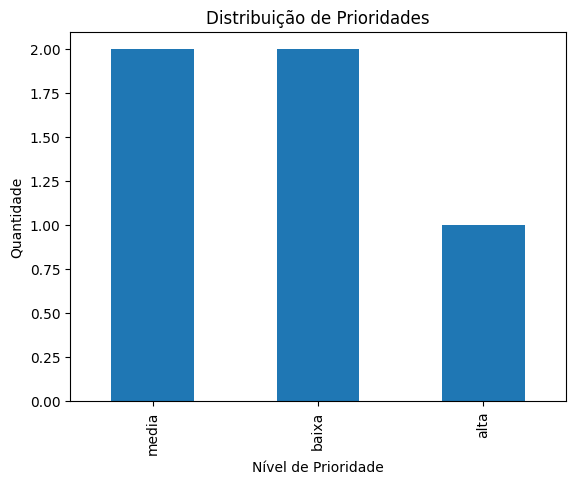

In [16]:
# =========================
# ANÁLISE DE COMPLEXIDADE
# =========================

# 1. Classificação com apply/map
# Complexidade: O(n)

# 2. Interações (operações vetorizadas)
# Complexidade: O(n)

# 3. Ordenação
# Complexidade: O(n log n)

# 4. Recursão (processamento de entregas)
# Complexidade: O(n)

# 5. Criação de estruturas (lista, dict, deque)
# Complexidade: O(n)

# =========================
# CONTAGEM
# =========================

contagem = df["categoria_prioridade"].value_counts()

# =========================
# GRÁFICO
# =========================

plt.figure()
contagem.plot(kind="bar")
plt.xlabel("Nível de Prioridade")
plt.ylabel("Quantidade")
plt.title("Distribuição de Prioridades")
plt.show()